# Discovery limit for hierarchical two axions

**Counting axions with IAXO** — B. Grinstein, C. Miró, P. Quílez (arXiv:2606.XXXXX). Unbinned likelihood analysis.

- **H1:** Two axions with $m_1 \ll m_2$ (hierarchical) and $\varphi=\pi/4$
  $$P \propto \frac{1}{4} + \frac{1}{4}\,{\rm sinc}^2\!\left(\frac{m_2^2 L}{4\omega}\right) + \frac{1}{2}\,{\rm sinc}\!\left(\frac{m_2^2 L}{4\omega}\right)\cos\!\left(\frac{m_2^2 L_{\rm ES}}{2\omega}\right)\times{\rm damping}$$
- **H0:** Single massive axion with fitted mass (profile likelihood over the H0 mass)

Scans over $m_2$ and computes the discrimination coupling $g_{a\gamma}^{\rm dis}(m_2)$
for energy resolutions $\omega_{\rm res} = 10,\,100,\,200$ eV.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

from iaxo_params import omega_min, omega_max, setup_plot_style
from conversion_prob import dN_domega
from test_statistic import compute_discovery_limit
from test_statistic import compute_profile_q0, g_discovery_from_q0

## Parameters

In [9]:
E_res_keV = 0.1           # Reference energy resolution [keV]
n_uniform = 80000         # Grid points

# m2 scan range
m2_min = 1e-3             # eV
m2_max = 2e-1             # eV
n_m2 = 100

m2_vals = np.logspace(np.log10(m2_min), np.log10(m2_max), n_m2)

# Load CAST exclusion and IAXO projection
data = np.loadtxt('input_data/CAST_exclusion.dat')
sqrt_dm2_data = data[:, 0]  # sqrt(Delta_m21^2) [eV]
g_CAST = data[:, 1]         # g exclusion CAST [GeV^-1]
# g_IAXO = data[:, 2]         # g projection IAXO [GeV^-1]

#IAXO projection 
dataIAXO = np.loadtxt('input_data/IAXO_projection.dat')
sqrt_dm2_data = dataIAXO[:, 0]  # sqrt(Delta_m21^2) [eV]
g_IAXO = dataIAXO[:, 1]         # g projection IAXO [GeV^-1]

#IAXO+ projection 
dataIAXOp = np.loadtxt('input_data/IAXOplus_projection.dat')
sqrt_dm2_data = dataIAXOp[:, 0]  # sqrt(Delta_m21^2) [eV]
g_IAXOp = dataIAXOp[:, 1]         # g projection IAXO [GeV^-1]

# Interpolation of CAST exclusion limit (log-log)
from scipy.interpolate import interp1d
g_CAST_interp = interp1d(np.log10(sqrt_dm2_data), np.log10(g_CAST),
                         kind='linear', fill_value='extrapolate')

## Compute discovery limits

Profile likelihood: for each two-axion H1 $(m_1=0,\ m_2)$, the H0 hypothesis is a
single massive axion whose mass is fitted to best mimic the H1 spectrum
(`compute_profile_q0` minimizes $q_0$ over the H0 mass).

For a faster generation of the plot, load the previously generated discovery limit saved in the  results_data folder two cells below.

Runtime for n_m2=100 is around XX min.

In [3]:
print("Hierarchical two axions (m1 << m2) vs single massive axion (fitted mass)")
print(f"m2 range: [{m2_min:.1e}, {m2_max:.1e}] eV, n_points = {n_m2}")

omega = np.linspace(omega_min, omega_max, n_uniform)
n_profile = len(m2_vals)

# H0 factory: single massive axion with mass m_null
def make_H0_massive(m_null):
    return lambda E, mn=m_null: dN_domega(E, m1=mn, m2=mn)

# Profile likelihood for 3 energy resolutions [keV]
E_res_profile_keV = [0.01, 0.1, 0.2]
results_profile = {}

for E_res_run in E_res_profile_keV:
    q0_arr = np.zeros(n_profile)
    m_hat_arr = np.zeros(n_profile)
    print(f"Profile: E_res = {int(E_res_run*1000)} eV, {n_profile} mass points")
    for i, m2 in enumerate(m2_vals):
        # Analytic damping with the correct E_res for this run
        dN_H1 = lambda E, m=m2, er=E_res_run: dN_domega(E, m1=0, m2=m, E_res_keV=er)
        q0_arr[i], m_hat_arr[i], _ = compute_profile_q0(
            dN_H1, make_H0_massive, omega, E_res_run,
            m_scan_min=m2_min*0.5, m_scan_max=m2_max*3, n_coarse=8,
            n_uniform=n_uniform)
        if (i+1) % max(1, n_profile//10) == 0 or i == 0:
            print(f"  [{i+1:3d}/{n_profile}] m2={m2:.2e} -> m_hat={m_hat_arr[i]:.2e}, q0/g4={q0_arr[i]:.2e}")
    results_profile[E_res_run] = {
        'q0':    q0_arr,
        'm_hat': m_hat_arr,
        'g_disc': g_discovery_from_q0(q0_arr),
    }
    print(f"  g_disc: [{np.nanmin(results_profile[E_res_run]['g_disc']):.3e}, "
          f"{np.nanmax(results_profile[E_res_run]['g_disc']):.3e}] GeV^-1\n")

Hierarchical two axions (m1 << m2) vs single massive axion (fitted mass)
m2 range: [1.0e-03, 2.0e-01] eV, n_points = 100
Profile: E_res = 10 eV, 100 mass points
  [  1/100] m2=1.00e-03 -> m_hat=8.41e-04, q0/g4=5.97e+31
  [ 10/100] m2=1.62e-03 -> m_hat=1.36e-03, q0/g4=1.20e+35
  [ 20/100] m2=2.76e-03 -> m_hat=2.28e-03, q0/g4=5.67e+38
  [ 30/100] m2=4.72e-03 -> m_hat=3.49e-03, q0/g4=6.80e+41
  [ 40/100] m2=8.06e-03 -> m_hat=5.28e-03, q0/g4=2.32e+43
  [ 50/100] m2=1.38e-02 -> m_hat=5.95e-03, q0/g4=1.68e+44
  [ 60/100] m2=2.35e-02 -> m_hat=3.10e-03, q0/g4=4.22e+43
  [ 70/100] m2=4.02e-02 -> m_hat=1.70e-03, q0/g4=3.35e+41
  [ 80/100] m2=6.86e-02 -> m_hat=9.90e-04, q0/g4=5.13e+39
  [ 90/100] m2=1.17e-01 -> m_hat=5.80e-04, q0/g4=6.99e+37
  [100/100] m2=2.00e-01 -> m_hat=5.00e-04, q0/g4=1.11e+36
  g_disc: [1.489e-11, 1.971e-08] GeV^-1

Profile: E_res = 100 eV, 100 mass points
  [  1/100] m2=1.00e-03 -> m_hat=8.41e-04, q0/g4=7.07e+30
  [ 10/100] m2=1.62e-03 -> m_hat=1.36e-03, q0/g4=1.74e+34
  [

In [4]:
# -- SAVE results to file --
_results_dir = 'results_data'
os.makedirs(_results_dir, exist_ok=True)

for E_res_run in E_res_profile_keV:
    fname = os.path.join(_results_dir, f'Hier_profile_Eres{int(E_res_run*1000)}eV.txt')
    data = np.column_stack([
        m2_vals,
        results_profile[E_res_run]['g_disc'],
        results_profile[E_res_run]['m_hat'],
        results_profile[E_res_run]['q0'],
    ])
    header = ('Counting axions with IAXO (arXiv:2606.XXXXX) by B. Grinstein, C. Miro and P. Quilez\n'
              '# Hierarchical g_discovery of 2 axions (profile likelihood) as a function of m2\n'
              '# m2_vals[eV]    g_disc[GeV^-1]    m_hat[eV]    q0_over_g4[GeV^-4]')
    np.savetxt(fname, data, header=header, fmt='%.6e')
    print(f"Saved:  {fname}")

Saved:  results_data/Hier_profile_Eres10eV.txt
Saved:  results_data/Hier_profile_Eres100eV.txt
Saved:  results_data/Hier_profile_Eres200eV.txt


In [10]:
# -- LOAD results from file (run this INSTEAD of the computation cell above) --
_results_dir = 'results_data'

E_res_profile_keV = [0.01, 0.1, 0.2]   # must match what was saved
results_profile = {}

for E_res_run in E_res_profile_keV:
    fname = os.path.join(_results_dir, f'Hier_profile_Eres{int(E_res_run*1000)}eV.txt')
    data = np.loadtxt(fname)            # columns: m2_vals, g_disc, m_hat, q0
    results_profile[E_res_run] = {
        'g_disc': data[:, 1],
        'm_hat':  data[:, 2],
        'q0':     data[:, 3],
    }
    print(f"Loaded: {fname}")

Loaded: results_data/Hier_profile_Eres10eV.txt
Loaded: results_data/Hier_profile_Eres100eV.txt
Loaded: results_data/Hier_profile_Eres200eV.txt


## Plot

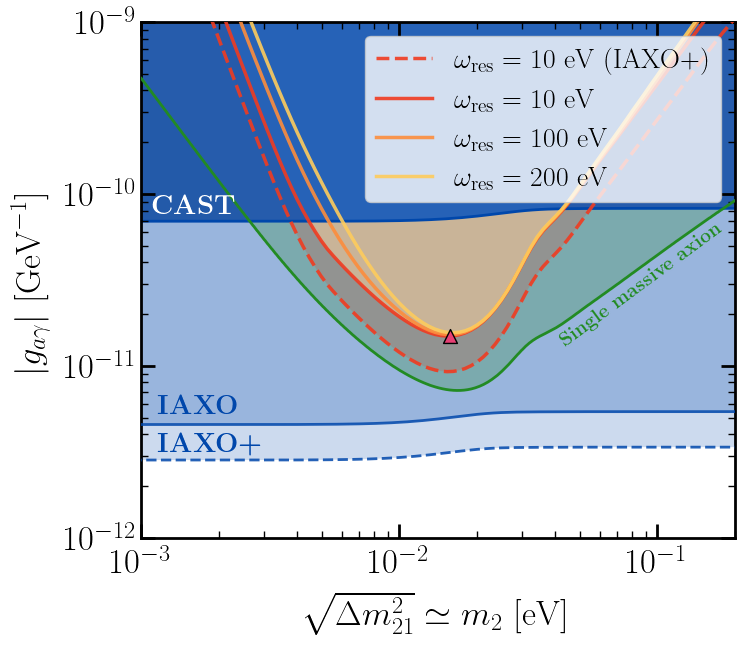

In [13]:
from palettable.colorbrewer.sequential import YlOrRd_5
from palettable.cartocolors.qualitative import Bold_10
import matplotlib.patheffects as pe

colorsBounds = ["#0047AB", "#0047AB", "#0047AB"]
colors = YlOrRd_5.mpl_colors[1:]
colorsMarkers = Bold_10.mpl_colors

def lighten(color, alpha):
    """Lighten a color as alpha would, but opaque."""
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(color))
    return tuple(alpha * c + (1 - alpha) * np.ones(3))

setup_plot_style()
fig, ax = plt.subplots(figsize=(8, 7))

# CAST exclusion
ax.loglog(sqrt_dm2_data, g_CAST, color=colorsBounds[2], lw=2, zorder=1)
ax.fill_between(sqrt_dm2_data, g_CAST, 1e-8, facecolor=colorsBounds[2], zorder=0.5, alpha=0.85)
ax.text(1.1e-3, (1.5/1.95)*1e-10, r'{\bf CAST}', fontsize=20, color='w', zorder=1000)

# IAXO projection
ax.fill_between(sqrt_dm2_data, g_IAXO, g_CAST, facecolor=colorsBounds[1], zorder=0.05, alpha=0.4)
ax.loglog(sqrt_dm2_data, g_IAXO, colorsBounds[1], lw=2, ls='-', zorder=8, alpha=0.85)
ax.text(1.15e-3, (1.2/2.3)*1e-11, r'{\bf IAXO}', fontsize=20, color=colorsBounds[1], zorder=1000)

# IAXO+ projection
ax.fill_between(sqrt_dm2_data, g_IAXOp, g_IAXO, facecolor=colorsBounds[0], zorder=0.05, alpha=0.2)
ax.loglog(sqrt_dm2_data, g_IAXOp, color=colorsBounds[0], lw=2, ls='--', zorder=8, alpha=0.85)
ax.text(1.15e-3, (3.15)*1e-12, r'{\bf IAXO+}', fontsize=20, color=colorsBounds[0], zorder=1000)

# IAXO+ discrimination projection (dashed)
ax.loglog(m2_vals, results_profile[0.01]['g_disc']*0.621, color=colors[2], lw=2.5, ls='--',
          label=r'$\omega_{\rm res} = 10\ \mathrm{eV}\ (\mathrm{IAXO+})$', zorder=9, alpha=0.9)
ax.fill_between(m2_vals, results_profile[0.01]['g_disc']*0.621, results_profile[0.01]['g_disc'],
                facecolor=colors[2], alpha=0.2, zorder=0.1)

# Profile likelihood discrimination limits (3 resolutions)
profile_colors = [colors[2], colors[1], colors[0]]  # 10, 100, 200 eV (light -> dark)
for E_res_run, col in zip(E_res_profile_keV, profile_colors):
    g_prof = results_profile[E_res_run]['g_disc']
    label = rf'$\omega_{{\rm res}} = {int(E_res_run*1000)}\ \mathrm{{eV}}$ '
    ax.loglog(m2_vals, g_prof, color=col, lw=2.5, ls='-', label=label, zorder=11, alpha=0.9)

# Fill: between 10 eV profile curve and CAST exclusion
lightened_yel = lighten(colors[1], 0.6)
ax.fill_between(m2_vals, results_profile[0.01]['g_disc'],
                10**g_CAST_interp(np.log10(m2_vals)),
                facecolor=lightened_yel, alpha=0.6, zorder=0.1)

# Single massive axion mass-measurement reference (Dafni et al.)
ciaran_data = np.loadtxt('input_data/[Weighing]MassDiscoveryLimit_Photon.txt')
ciaran_mass = ciaran_data[0, :]
ciaran_g = ciaran_data[4, :]  # E0 = 100 eV resolution
ax.loglog(ciaran_mass, ciaran_g, "forestgreen", lw=2, ls='-', zorder=9, alpha=0.995)
ax.fill_between(ciaran_mass, ciaran_g, 10**g_CAST_interp(np.log10(ciaran_mass)),
                facecolor='forestgreen', alpha=0.25, zorder=0.05)
ax.text(4.1e-2, 1.3e-11, r'{\bf Single massive axion}', fontsize=14,
        color='forestgreen', zorder=1000, rotation=36.5)

# Optimal point marker
ax.scatter(1.57e-2, 1.5e-11, color=colorsMarkers[4], s=100, zorder=50,
           marker='^', edgecolor='black')

ax.set_xlabel(r"$\sqrt{\Delta m_{21}^2}\simeq m_2\ [\mathrm{eV}]$", labelpad=10)
ax.set_ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$", labelpad=10)
ax.set_xlim([m2_min, m2_max])
ax.set_ylim([1e-12, 1e-9])
ax.tick_params(axis='x', which='major', pad=8)
ax.tick_params(axis='x', which='minor', pad=8)

leg = ax.legend(fontsize=20, loc='upper right')
leg.set_zorder(20)
ax.set_zorder(100)
ax.set_axisbelow(False)

plt.tight_layout()

os.makedirs('plots', exist_ok=True)
fig.savefig('plots/Hierarchical_disc.pdf', bbox_inches='tight')
fig.savefig('plots/Hierarchical_disc.png', bbox_inches='tight')
plt.show()

# Optional: save directly into the Overleaf paper folder with the paper's figure names
save_overleaf = False
overleaf_dir = ('/home/pabloql/Cloud/Dropbox/Aplicaciones/Overleaf/'
                'Counting axions with helioscopes/plots')
if save_overleaf and os.path.isdir(overleaf_dir):
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(overleaf_dir, 'Hierarchical_discovery.' + ext),
                    bbox_inches='tight')
    print('Saved to Overleaf: Hierarchical_discovery.pdf/.png')